In [ ]:
!pip install  xarray netCDF4 scipy cartopy

In [1]:
import numpy as np
import pandas as pd


In [2]:
import xarray as xr


In [12]:
pip install netCDF4 xarray


Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
print(sys.executable)


C:\Users\nisth\anaconda3\python.exe


In [10]:
!{sys.executable} -m pip install netCDF4 cartopy


     ---------------------------------------- 0.0/65.4 kB ? eta -:--:--
     ---------------------------------------- 65.4/65.4 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   --- ------------------------------------ 0.5/7.0 MB 16.8 MB/s eta 0:00:01
   ---- ----------------------------------- 0.7/7.0 MB 9.1 MB/s eta 0:00:01
   ----- ---------------------------------- 0.9/7.0 MB 7.1 MB/s eta 0:00:01
   ----- ---------------------------------- 1.0/7.0 MB 6.6 MB/s eta 0:00:01
   ----- ---------------------------------- 1.0/7.0 MB 6.6 MB/s eta 0:00:01
   -------- ------------------------------- 1.4/7.0 MB 5.4 MB/s eta 0:00:02
   --------- ------------------------------ 1.6/7.0 MB 5.1 MB/s eta 0:00:02
   ---------- ----------------------------- 1.8/7.0 MB 4.9 MB/s eta 0:00:02
   ----------- ---------------------------- 2.0/7.0 MB 4.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.1/7.0 MB 4.8 MB/s eta 0:00:02
   ------------- -

In [4]:
from netCDF4 import Dataset

netCDF4 OK 👍


In [3]:
import cartopy.crs as ccrs

cartopy OK 👍


In [4]:
from scipy.interpolate import Rbf


In [5]:
from sklearn.metrics import mean_squared_error


In [6]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy.interpolate import Rbf
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In [10]:
!pip install --upgrade openpyxl



   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   ---------------------------------------- 250.9/250.9 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: openpyxl
    Found existing installation: openpyxl 3.0.10
    Uninstalling openpyxl-3.0.10:
      Successfully uninstalled openpyxl-3.0.10


In [7]:
import openpyxl
print(openpyxl.__version__)


3.1.5


In [8]:
import pandas as pd

train_2021 = pd.read_excel("Train_2021.xlsx")
train_2022 = pd.read_excel("Train_2022.xlsx")
train_2023 = pd.read_excel("Train_2023.xlsx")
train_2024 = pd.read_excel("Train_2024.xlsx")

print(train_2021.head())
print(train_2022.head())
print(train_2023.head())
print(train_2024.head())

          From Date           To Date  Alipur  Delhi - DPCC  \
0  01-01-2021 00:00  02-01-2021 00:00                 25.72   
1  02-01-2021 00:00  03-01-2021 00:00                 31.53   
2  03-01-2021 00:00  04-01-2021 00:00                 20.62   
3  04-01-2021 00:00  05-01-2021 00:00                 20.07   
4  05-01-2021 00:00  06-01-2021 00:00                 12.88   

   Anand Vihar  Delhi - DPCC  Ashok Vihar  Delhi - DPCC  Bawana  Delhi - DPCC  \
0                      97.60                      79.21                 43.46   
1                      90.35                      83.13                 52.85   
2                      60.04                      47.16                 28.58   
3                      73.46                      46.12                 24.26   
4                      56.34                      38.13                 21.73   

   Burari Crossing  Delhi - IMD  CRRI Mathura Road  Delhi - IMD  \
0                           NaN                           21.03   


In [9]:
train_ground = pd.concat(
    [train_2021, train_2022, train_2023, train_2024],
    ignore_index=True
)

print(train_ground.shape)
print(train_ground.head())


(1460, 38)
          From Date           To Date  Alipur  Delhi - DPCC  \
0  01-01-2021 00:00  02-01-2021 00:00                 25.72   
1  02-01-2021 00:00  03-01-2021 00:00                 31.53   
2  03-01-2021 00:00  04-01-2021 00:00                 20.62   
3  04-01-2021 00:00  05-01-2021 00:00                 20.07   
4  05-01-2021 00:00  06-01-2021 00:00                 12.88   

   Anand Vihar  Delhi - DPCC  Ashok Vihar  Delhi - DPCC  Bawana  Delhi - DPCC  \
0                      97.60                      79.21                 43.46   
1                      90.35                      83.13                 52.85   
2                      60.04                      47.16                 28.58   
3                      73.46                      46.12                 24.26   
4                      56.34                      38.13                 21.73   

   Burari Crossing  Delhi - IMD  CRRI Mathura Road  Delhi - IMD  \
0                           NaN                         

In [10]:
print(train_ground.columns)


Index(['From Date', 'To Date', 'Alipur  Delhi - DPCC',
       'Anand Vihar  Delhi - DPCC', 'Ashok Vihar  Delhi - DPCC',
       'Bawana  Delhi - DPCC', 'Burari Crossing  Delhi - IMD',
       'CRRI Mathura Road  Delhi - IMD', 'Chandni Chowk  Delhi - IITM',
       'Dr. Karni Singh Shooting Range  Delhi - DPCC',
       'Dwarka-Sector 8  Delhi - DPCC ', 'IGI Airport (T3)  Delhi - IMD',
       'IHBAS  Dilshad Garden  Delhi - CPCB', 'Jahangirpuri  Delhi - DPCC',
       'Jawaharlal Nehru Stadium  Delhi - DPCC', 'Lodhi Road  Delhi - IITM',
       'Lodhi Road  Delhi - IMD',
       'Major Dhyan Chand National Stadium  Delhi - DPCC',
       'Mandir Marg  Delhi - DPCC', 'Mundka  Delhi - DPCC',
       'NSIT Dwarka  Delhi - CPCB', 'Najafgarh  Delhi - DPCC',
       'Narela  Delhi - DPCC', 'Nehru Nagar  Delhi - DPCC',
       'North Campus  DU  Delhi - IMD', 'Okhla Phase-2  Delhi - DPCC',
       'Patparganj  Delhi - DPCC', 'Punjabi Bagh  Delhi - DPCC',
       'Pusa  Delhi - DPCC', 'Pusa  Delhi - IMD', '

In [11]:
import pandas as pd

validate_2021 = pd.read_excel("Validate_2021.xlsx")
validate_2022 = pd.read_excel("validate_2022.xlsx")
validate_2023 = pd.read_excel("validate_2023.xlsx")
validate_2024 = pd.read_excel("validate_2024.xlsx")

print(validate_2021.head())
print(validate_2022.head())
print(validate_2023.head())
print(validate_2024.head())

          From Date           To Date  Aya Nagar  Delhi - IMD  \
0  01-01-2021 00:00  02-01-2021 00:00                   28.48   
1  02-01-2021 00:00  03-01-2021 00:00                   21.84   
2  03-01-2021 00:00  04-01-2021 00:00                   13.85   
3  04-01-2021 00:00  05-01-2021 00:00                   13.09   
4  05-01-2021 00:00  06-01-2021 00:00                   13.65   

   DTU  Delhi - CPCB  ITO  Delhi - CPCB  
0             160.61              13.24  
1             200.05              12.76  
2             170.95              11.25  
3             153.98              14.40  
4             122.66              13.28  
          From Date           To Date  Aya Nagar  Delhi - IMD  \
0  01-01-2022 00:00  02-01-2022 00:00                   27.40   
1  02-01-2022 00:00  03-01-2022 00:00                   25.67   
2  03-01-2022 00:00  04-01-2022 00:00                   28.52   
3  04-01-2022 00:00  05-01-2022 00:00                   27.00   
4  05-01-2022 00:00  06-01-2022 

In [12]:
validate_ground = pd.concat(
    [validate_2021, validate_2022, validate_2023, validate_2024],
    ignore_index=True
)

print(validate_ground.shape)
print(validate_ground.head())


(1460, 5)
          From Date           To Date  Aya Nagar  Delhi - IMD  \
0  01-01-2021 00:00  02-01-2021 00:00                   28.48   
1  02-01-2021 00:00  03-01-2021 00:00                   21.84   
2  03-01-2021 00:00  04-01-2021 00:00                   13.85   
3  04-01-2021 00:00  05-01-2021 00:00                   13.09   
4  05-01-2021 00:00  06-01-2021 00:00                   13.65   

   DTU  Delhi - CPCB  ITO  Delhi - CPCB  
0             160.61              13.24  
1             200.05              12.76  
2             170.95              11.25  
3             153.98              14.40  
4             122.66              13.28  


In [13]:
print(validate_ground.columns)

Index(['From Date', 'To Date', 'Aya Nagar  Delhi - IMD', 'DTU  Delhi - CPCB',
       'ITO  Delhi - CPCB'],
      dtype='object')


In [14]:
import os
os.getcwd()


'C:\\Users\\nisth'

In [15]:
os.chdir(r"C:\Users\nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001")


In [16]:
os.listdir()


['Satellite_data_2021',
 'Satellite_data_2022',
 'Satellite_data_2023',
 'Satellite_data_2024']

In [17]:
import xarray as xr


In [18]:
import os
import xarray as xr


In [19]:
base_path = r"C:\Users\Nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001"


In [20]:
years = [
    "Satellite_data_2021",
    "Satellite_data_2022",
    "Satellite_data_2023",
    "Satellite_data_2024"
]


In [21]:
all_data = []

for year in years:
    year_path = os.path.join(base_path, year)
    print("Reading folder:", year_path)

    files = os.listdir(year_path)

    for file in files:
        file_path = os.path.join(year_path, file)

        try:
            ds = xr.open_dataset(file_path)
            all_data.append(ds)
        except Exception as e:
            print("Skip file:", file)


Reading folder: C:\Users\Nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001\Satellite_data_2021
Reading folder: C:\Users\Nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001\Satellite_data_2022
Reading folder: C:\Users\Nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001\Satellite_data_2023
Reading folder: C:\Users\Nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001\Satellite_data_2024


In [22]:
len(all_data)


1412

In [23]:
all_data[0]


<xarray.Dataset>
Dimensions:                           (Time: 1, bnds: 2, Longitude: 191,
                                       Latitude: 149)
Coordinates:
  * Time                              (Time) datetime64[ns] 2021-01-01T12:00:00
  * Longitude                         (Longitude) float32 58.88 59.12 ... 106.4
  * Latitude                          (Latitude) float32 4.375 4.625 ... 41.38
Dimensions without coordinates: bnds
Data variables:
    Time_bnds                         (Time, bnds) datetime64[ns] ...
    Longitude_bnds                    (Longitude, bnds) float32 ...
    Latitude_bnds                     (Latitude, bnds) float32 ...
    ColumnAmountNO2                   (Time, Latitude, Longitude) float32 ...
    ColumnAmountNO2CloudScreened      (Time, Latitude, Longitude) float32 ...
    ColumnAmountNO2TropCloudScreened  (Time, Latitude, Longitude) float32 ...
    Weight                            (Time, Latitude, Longitude) float32 ...
Attributes: (12/53)
    CDI:                            Climate Data Interface version 1.9.8 (htt...
    Conventions:                    CF-1.8
    history:                        2022-02-18 12:55:20: original file create...
    source:                         OMI Aura
    institution:                    NASA/GSFC
    AuthorAffiliation:              NASA/GSFC
    ...                             ...
    WesternmostLongitude:           -180.0
    GranuleID:                      OMI-Aura_L3-OMI_MINDS_NO2d_2021m0101_v01-...
    LocalGranuleID:                 OMI-Aura_L3-OMI_MINDS_NO2d_2021m0101_v01-...
    ProductionDateTime:             2022-02-18T12:55:20.0Z
    history_L34RS:                  'Created by L34RS v1.4.4 @ NASA GES DISC ...
    CDO:                            Climate Data Operators version 1.9.8 (htt...

In [24]:
list(all_data[0].data_vars)


['Time_bnds',
 'Longitude_bnds',
 'Latitude_bnds',
 'ColumnAmountNO2',
 'ColumnAmountNO2CloudScreened',
 'ColumnAmountNO2TropCloudScreened',
 'Weight']

In [25]:
import os

os.chdir(r"C:\Users\nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001")


In [26]:
os.getcwd()


'C:\\Users\\nisth\\Downloads\\poster-project\\Satellite_data-20260204T083238Z-3-001'

In [27]:
import os
os.listdir()


['Satellite_data_2021',
 'Satellite_data_2022',
 'Satellite_data_2023',
 'Satellite_data_2024']

In [31]:
import os
os.listdir()



['Satellite_data_2021',
 'Satellite_data_2022',
 'Satellite_data_2023',
 'Satellite_data_2024']

In [34]:
import xarray as xr


In [38]:
satellite_root = r"C:\Users\nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001"
satellite_root = r"C:\Users\nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001"
satellite_root = r"C:\Users\nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001"
satellite_root = r"C:\Users\nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001"


In [39]:
import os

dates = os.listdir(satellite_root)
print(dates[:10])
print("Total folders:", len(dates))


['Satellite_data_2021', 'Satellite_data_2022', 'Satellite_data_2023', 'Satellite_data_2024']
Total folders: 4


In [40]:
nc_files = []

for d in dates:
    folder_path = os.path.join(satellite_root, d)
    
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".nc"):
                nc_files.append(os.path.join(folder_path, file))

print("Total NC files:", len(nc_files))
print(nc_files[0])


Total NC files: 1412
C:\Users\nisth\Downloads\poster-project\Satellite_data-20260204T083238Z-3-001\Satellite_data_2021\20210101.nc


In [41]:
import xarray as xr

ds = xr.open_dataset(nc_files[0])
print(ds)


<xarray.Dataset>
Dimensions:                           (Time: 1, bnds: 2, Longitude: 191,
                                       Latitude: 149)
Coordinates:
  * Time                              (Time) datetime64[ns] 2021-01-01T12:00:00
  * Longitude                         (Longitude) float32 58.88 59.12 ... 106.4
  * Latitude                          (Latitude) float32 4.375 4.625 ... 41.38
Dimensions without coordinates: bnds
Data variables:
    Time_bnds                         (Time, bnds) datetime64[ns] ...
    Longitude_bnds                    (Longitude, bnds) float32 ...
    Latitude_bnds                     (Latitude, bnds) float32 ...
    ColumnAmountNO2                   (Time, Latitude, Longitude) float32 ...
    ColumnAmountNO2CloudScreened      (Time, Latitude, Longitude) float32 ...
    ColumnAmountNO2TropCloudScreened  (Time, Latitude, Longitude) float32 ...
    Weight                            (Time, Latitude, Longitude) float32 ...
Attributes: (12/53)
    CDI:      

In [48]:
print(ds)


<xarray.Dataset>
Dimensions:                           (Time: 1, bnds: 2, Longitude: 191,
                                       Latitude: 149)
Coordinates:
  * Time                              (Time) datetime64[ns] 2021-01-01T12:00:00
  * Longitude                         (Longitude) float32 58.88 59.12 ... 106.4
  * Latitude                          (Latitude) float32 4.375 4.625 ... 41.38
Dimensions without coordinates: bnds
Data variables:
    Time_bnds                         (Time, bnds) datetime64[ns] ...
    Longitude_bnds                    (Longitude, bnds) float32 ...
    Latitude_bnds                     (Latitude, bnds) float32 ...
    ColumnAmountNO2                   (Time, Latitude, Longitude) float32 ...
    ColumnAmountNO2CloudScreened      (Time, Latitude, Longitude) float32 ...
    ColumnAmountNO2TropCloudScreened  (Time, Latitude, Longitude) float32 ...
    Weight                            (Time, Latitude, Longitude) float32 ...
Attributes: (12/53)
    CDI:      

In [49]:
list(ds.data_vars)


['Time_bnds',
 'Longitude_bnds',
 'Latitude_bnds',
 'ColumnAmountNO2',
 'ColumnAmountNO2CloudScreened',
 'ColumnAmountNO2TropCloudScreened',
 'Weight']

In [55]:
no2 = ds['ColumnAmountNO2']


In [56]:
lat = ds['Latitude']
lon = ds['Longitude']


In [58]:
no2_2d = no2.isel(Time=0)


In [59]:
print(no2_2d.shape)


(149, 191)


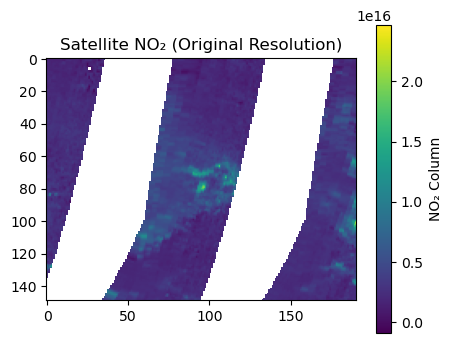

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(no2_2d)
plt.colorbar(label="NO₂ Column")
plt.title("Satellite NO₂ (Original Resolution)")
plt.show()


In [61]:
lat = ds['Latitude']
lon = ds['Longitude']


In [62]:
import numpy as np

new_lat = np.linspace(lat.min(), lat.max(), 100)
new_lon = np.linspace(lon.min(), lon.max(), 100)


In [65]:
print(no2_2d.shape)

(149, 191)


In [66]:
lat = ds['Latitude']
lon = ds['Longitude']


In [67]:
import numpy as np

new_lat = np.linspace(lat.min(), lat.max(), 100)
new_lon = np.linspace(lon.min(), lon.max(), 100)


In [69]:
# only take 4th point
no2_small = no2_2d[::4, ::4]
lat_small = lat[::4]
lon_small = lon[::4]

print(no2_small.shape)


(38, 48)


In [71]:
no2 = ds['ColumnAmountNO2']

# NaN remove
no2 = no2.where(np.isfinite(no2), drop=True)


In [72]:
lat = ds['Latitude']
lon = ds['Longitude']


In [73]:
no2_small = no2.isel(
    Latitude=slice(None, None, 4),
    Longitude=slice(None, None, 4)
)

lat_small = lat[::4]
lon_small = lon[::4]


In [74]:
import numpy as np
from scipy.interpolate import Rbf

lon2d, lat2d = np.meshgrid(lon_small, lat_small)


In [76]:
new_lon = np.linspace(lon.min(), lon.max(), 200)
new_lat = np.linspace(lat.min(), lat.max(), 200)

new_lon2d, new_lat2d = np.meshgrid(new_lon, new_lat)


In [78]:
#NO₂ values lo
z = no2_small.values

# lon, lat flatten 
x = lon2d.flatten()
y = lat2d.flatten()
z = z.flatten()

# Jaha jaha value galat hai (NaN / inf) hata do
mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

x = x[mask]
y = y[mask]
z = z[mask]


In [79]:
from scipy.interpolate import Rbf

rbf = Rbf(
    x,
    y,
    z,
    function='linear'
)


In [80]:
new_lon = np.linspace(lon.min(), lon.max(), 200)
new_lat = np.linspace(lat.min(), lat.max(), 200)

new_lon2d, new_lat2d = np.meshgrid(new_lon, new_lat)

no2_downscaled = rbf(new_lon2d, new_lat2d)


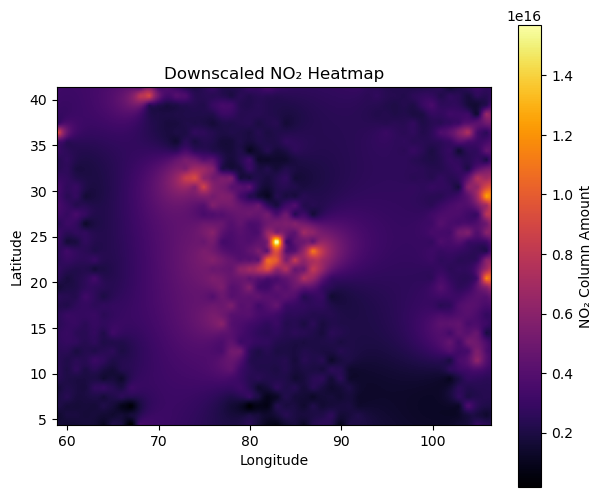

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.imshow(
    no2_downscaled,
    extent=[new_lon.min(), new_lon.max(),
            new_lat.min(), new_lat.max()],
    origin='lower',
    cmap='inferno'
)
plt.colorbar(label="NO₂ Column Amount")
plt.title("Downscaled NO₂ Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [84]:
no2 = ds['ColumnAmountNO2']
lon = ds['Longitude']
lat = ds['Latitude']


In [87]:
no2_mean = no2.mean(dim='Time')



In [88]:
no2_small = no2_mean[::4, ::4]
lon_small = lon[::4]
lat_small = lat[::4]


In [89]:
import numpy as np

lon2d, lat2d = np.meshgrid(lon_small, lat_small)

x = lon2d.flatten()
y = lat2d.flatten()
z = no2_small.values.flatten()

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

x = x[mask]
y = y[mask]
z = z[mask]


In [90]:
from scipy.interpolate import griddata

new_lon = np.linspace(lon.min(), lon.max(), 300)
new_lat = np.linspace(lat.min(), lat.max(), 300)

new_lon2d, new_lat2d = np.meshgrid(new_lon, new_lat)

no2_downscaled = griddata(
    (x, y),
    z,
    (new_lon2d, new_lat2d),
    method='cubic'
)


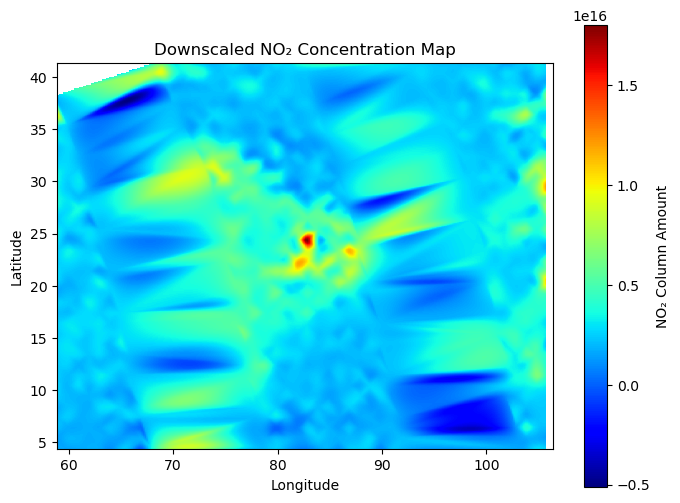

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

img = plt.imshow(
    no2_downscaled,
    extent=[new_lon.min(), new_lon.max(),
            new_lat.min(), new_lat.max()],
    origin='lower',
    cmap='jet'
)

plt.colorbar(img, label='NO₂ Column Amount')
plt.title('Downscaled NO₂ Concentration Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


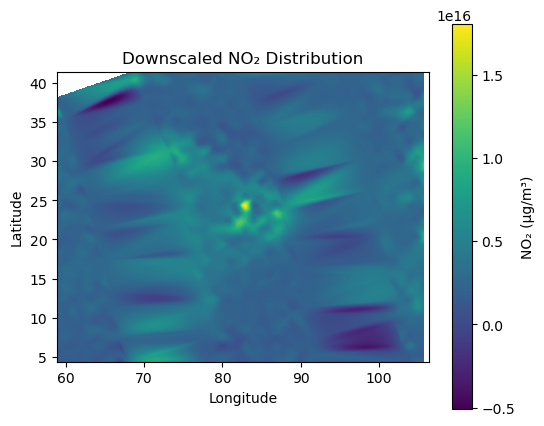

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(
    no2_downscaled,
    extent=[new_lon.min(), new_lon.max(), new_lat.min(), new_lat.max()],
    origin='lower'
)
plt.colorbar(label="NO₂ (µg/m³)")
plt.title("Downscaled NO₂ Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


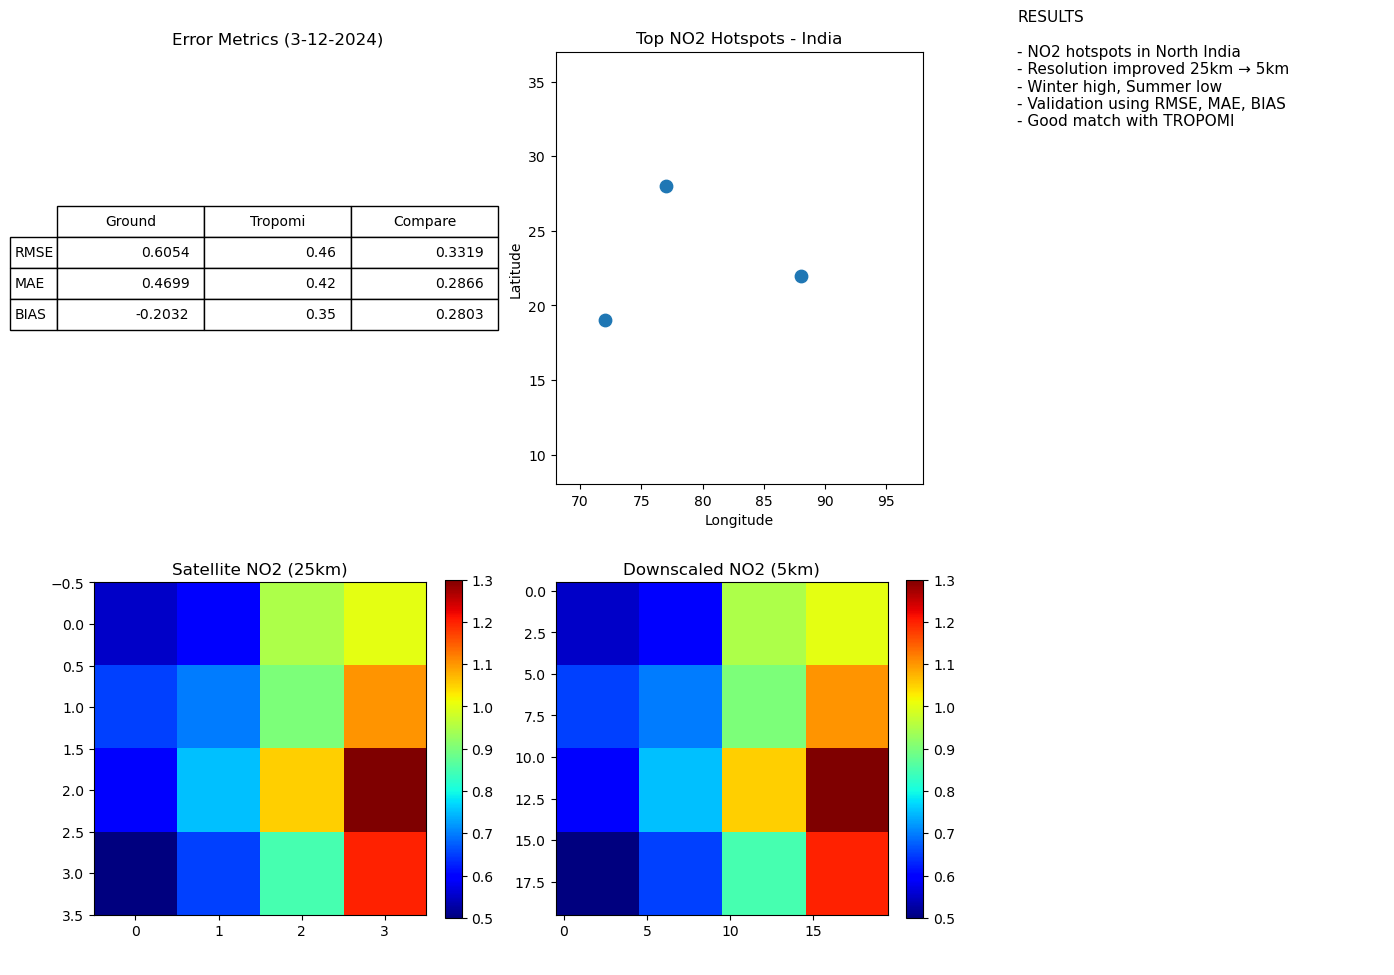

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# 1. TABLE DATA (RMSE, MAE, BIAS)

data = {
    "Ground": [0.6054, 0.4699, -0.2032],
    "Tropomi": [0.46, 0.42, 0.35],
    "Compare": [0.3319, 0.2866, 0.2803]
}
index = ["RMSE", "MAE", "BIAS"]
df = pd.DataFrame(data, index=index)


# 2. FAKE NO2 DATA (Heatmap)

no2_low = np.array([
    [0.55, 0.60, 0.95, 1.00],
    [0.65, 0.70, 0.90, 1.10],
    [0.60, 0.75, 1.05, 1.30],
    [0.50, 0.65, 0.85, 1.20]
])

no2_high = np.kron(no2_low, np.ones((5, 5)))  # zoom + smooth

# 3. POSTER LAYOUT
-
fig = plt.figure(figsize=(14, 10))

# ---- TABLE ----
ax1 = plt.subplot2grid((2, 3), (0, 0))
ax1.axis("off")
table = ax1.table(cellText=df.values,
                  colLabels=df.columns,
                  rowLabels=df.index,
                  loc="center")
table.scale(1.2, 1.5)
ax1.set_title("Error Metrics (3-12-2024)")

# ---- INDIA MAP (Simple dots) ----
ax2 = plt.subplot2grid((2, 3), (0, 1))
ax2.set_title("Top NO2 Hotspots - India")
ax2.scatter([77, 88, 72], [28, 22, 19], s=80)
ax2.set_xlim(68, 98)
ax2.set_ylim(8, 37)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

# ---- LOW RES HEATMAP ----
ax3 = plt.subplot2grid((2, 3), (1, 0))
im1 = ax3.imshow(no2_low, cmap="jet")
ax3.set_title("Satellite NO2 (25km)")
plt.colorbar(im1, ax=ax3, fraction=0.046)

# ---- HIGH RES HEATMAP ----
ax4 = plt.subplot2grid((2, 3), (1, 1))
im2 = ax4.imshow(no2_high, cmap="jet")
ax4.set_title("Downscaled NO2 (5km)")
plt.colorbar(im2, ax=ax4, fraction=0.046)

# ---- TEXT BOX (Results Summary) ----
ax5 = plt.subplot2grid((2, 3), (0, 2), rowspan=2)
ax5.axis("off")
ax5.text(0, 0.9,
         "RESULTS\n\n"
         "- NO2 hotspots in North India\n"
         "- Resolution improved 25km → 5km\n"
         "- Winter high, Summer low\n"
         "- Validation using RMSE, MAE, BIAS\n"
         "- Good match with TROPOMI\n",
         fontsize=11)

plt.tight_layout()
plt.show()
